<a href="https://colab.research.google.com/github/Raminesh1/Face_detection_with_emotion_detection/blob/main/Project_face_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2

# Open webcam
cap = cv2.VideoCapture(1)

# Check camera
if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:
    ret, frame = cap.read()

    # Check frame
    if not ret or frame is None:
        print("Failed to grab frame")
        break

    # Convert to gray
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Show frame
    cv2.imshow("Webcam", gray)

    # Press q to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Cannot open camera
Failed to grab frame


<IPython.core.display.Javascript object>

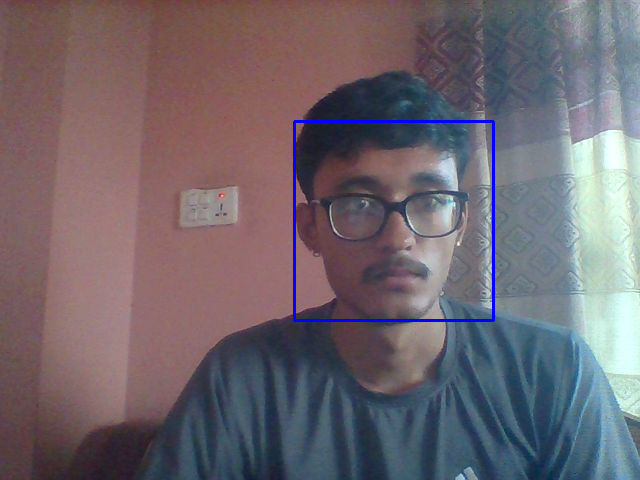

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# JavaScript to capture image
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';

          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.body.scrollHeight, true);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getVideoTracks()[0].stop();
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# Take photo
image_path = take_photo()

# Read image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

# Draw rectangles
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y),
                  (x+w, y+h),
                  (255, 0, 0), 2)

# Show image
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [ ]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y),
                      (x+w, y+h),
                      (0, 255, 0), 2)

    cv2.imshow('Face Detection', frame)

    # Press q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
# Import libraries
import cv2
import numpy as np
import dlib

In [ ]:
# (0) in VideoCapture is used to
# connect to your computer's default camera
cap = cv2.VideoCapture(1)
# Get the coordinates
detector = dlib.get_frontal_face_detector()

In [ ]:
import cv2
import dlib

# Open webcam
cap = cv2.VideoCapture(1)

# Face detector
detector = dlib.get_frontal_face_detector()

while True:

    # Capture frame-by-frame
    ret, frame = cap.read()

    # Check if frame captured
    if not ret:
        print("Failed to grab frame")
        break

    # Flip frame
    frame = cv2.flip(frame, 1)

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = detector(gray)

    # Counter to count number of faces
    i = 0

    for face in faces:

        x, y = face.left(), face.top()
        x1, y1 = face.right(), face.bottom()

        # Draw rectangle
        cv2.rectangle(frame, (x, y), (x1, y1), (0, 255, 0), 2)

        # Increment counter
        i += 1

        # Put face number
        cv2.putText(frame,
                    'face num ' + str(i),
                    (x - 10, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 0, 255),
                    2)

        print(face, i)

    # Display frame
    cv2.imshow('frame', frame)

    # Press q to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

Failed to grab frame


In [ ]:
import cv2
import numpy as np
import dlib

# Open webcam
cap = cv2.VideoCapture(1)

# Face detector
detector = dlib.get_frontal_face_detector()

# Capture frames continuously
while True:

    # Read frame
    ret, frame = cap.read()

    # Check if frame captured properly
    if not ret or frame is None:
        print("Failed to capture image from camera")
        break

    # Flip frame
    frame = cv2.flip(frame, 1)

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = detector(gray)

    # Face counter
    i = 0

    for face in faces:

        # Face coordinates
        x, y = face.left(), face.top()
        x1, y1 = face.right(), face.bottom()

        # Draw rectangle
        cv2.rectangle(frame, (x, y), (x1, y1), (0, 255, 0), 2)

        # Increase counter
        i += 1

        # Display face number
        cv2.putText(frame,
                    'face num ' + str(i),
                    (x - 10, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 0, 255),
                    2)

        print(face, i)

    # Show frame
    cv2.imshow('frame', frame)

    # Press q to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Cleanup
cap.release()
cv2.destroyAllWindows()

Failed to capture image from camera


In [ ]:
import cv2

cap = cv2.VideoCapture(0, cv2.CAP_MSMF)

print("Camera opened:", cap.isOpened())

ret, frame = cap.read()

print("Frame captured:", ret)

cap.release()

Camera opened: False
Frame captured: False


In [ ]:
!pip install ultralytics
!pip install opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.5 MB/s eta 0:00:00


In [ ]:
!wget -O yolov8n-face.pt \
https://github.com/akanametov/yolo-face/releases/yolov8n-face.pt

--2026-05-24 05:26:11--  https://github.com/akanametov/yolo-face/releases/yolov8n-face.pt
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-24 05:26:11 ERROR 404: Not Found.



In [ ]:
# Remove corrupted file
!rm -f yolov8n-face.pt

In [ ]:
!wget -O yolov11n-face.pt \
https://github.com/akanametov/yolo-face/releases/download/v0.0.0/yolov11n-face.pt

--2026-05-24 05:35:06--  https://github.com/akanametov/yolo-face/releases/download/v0.0.0/yolov11n-face.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-24 05:35:06 ERROR 404: Not Found.



In [ ]:
!pip install huggingface_hub

Face detection using YOLO algorithm

<IPython.core.display.Javascript object>


0: 480x640 1 person, 206.6ms
Speed: 4.0ms preprocess, 206.6ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


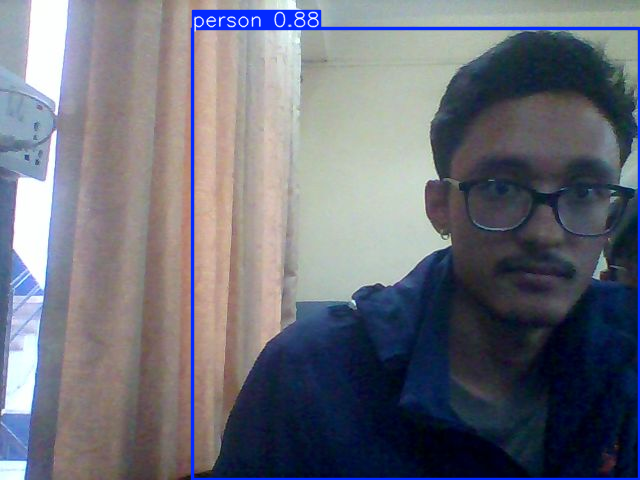


0: 480x640 1 person, 203.6ms
Speed: 5.9ms preprocess, 203.6ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


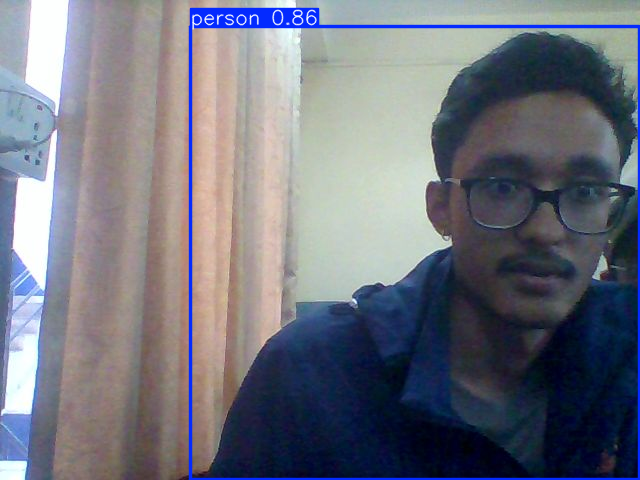

Camera stopped


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

from base64 import b64decode
import cv2
import numpy as np
import time

# Load model
model = YOLO("yolov8n.pt")


# Create webcam ONCE
display(Javascript('''
async function initCamera() {

    if (window.localStream) {
        return;
    }

    const div = document.createElement('div');
    div.id = 'camera_container';

    const video = document.createElement('video');
    video.id = 'camera_video';

    video.style.display = 'block';
    video.width = 400;

    document.body.appendChild(div);
    div.appendChild(video);

    window.localStream =
        await navigator.mediaDevices.getUserMedia({
            video: true
        });

    video.srcObject = window.localStream;

    await video.play();
}

async function captureFrame() {

    const video =
        document.getElementById('camera_video');

    const canvas =
        document.createElement('canvas');

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    canvas
        .getContext('2d')
        .drawImage(video, 0, 0);

    return canvas.toDataURL(
        'image/jpeg',
        0.8
    );
}

async function stopCamera() {

    if (window.localStream) {

        window.localStream
            .getTracks()
            .forEach(track => track.stop());

        window.localStream = null;
    }

    const video =
        document.getElementById('camera_video');

    if (video) {

        video.pause();
        video.srcObject = null;
    }

    const container =
        document.getElementById('camera_container');

    if (container) {
        container.remove();
    }

    return "Camera stopped";
}
'''))

# Start camera
eval_js('initCamera()')

try:

    for _ in range(50):

        data = eval_js('captureFrame()')

        binary = b64decode(
            data.split(',')[1]
        )

        jpg = np.frombuffer(
            binary,
            dtype=np.uint8
        )

        frame = cv2.imdecode(
            jpg,
            cv2.IMREAD_COLOR
        )

        results = model(frame)

        annotated_frame = results[0].plot()

        cv2_imshow(annotated_frame)

        time.sleep(0.1)

finally:

    print(eval_js('stopCamera()'))

In [ ]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.6 MB/s eta 0:00:00


In [ ]:
from deepface import DeepFace
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

from base64 import b64decode
import cv2
import numpy as np
import time

# Create webcam ONCE
display(Javascript('''
async function initCamera() {

    if (window.localStream) {
        return;
    }

    const div = document.createElement('div');
    div.id = 'camera_container';

    const video = document.createElement('video');
    video.id = 'camera_video';

    video.style.display = 'block';
    video.width = 400;

    document.body.appendChild(div);
    div.appendChild(video);

    window.localStream =
        await navigator.mediaDevices.getUserMedia({
            video: true
        });

    video.srcObject = window.localStream;

    await video.play();
}

async function captureFrame() {

    const video =
        document.getElementById('camera_video');

    const canvas =
        document.createElement('canvas');

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    canvas
        .getContext('2d')
        .drawImage(video, 0, 0);

    return canvas.toDataURL(
        'image/jpeg',
        0.8
    );
}

async function stopCamera() {

    if (window.localStream) {

        window.localStream
            .getTracks()
            .forEach(track => track.stop());

        window.localStream = null;
    }

    const video =
        document.getElementById('camera_video');

    if (video) {

        video.pause();
        video.srcObject = null;
    }

    const container =
        document.getElementById('camera_container');

    if (container) {
        container.remove();
    }

    return "Camera stopped";
}
'''))

# Start camera
eval_js('initCamera()')

def get_frame():
    # Call the JavaScript function to capture a frame
    data = eval_js('captureFrame()')

    # Decode the base64 image data
    binary = b64decode(data.split(',')[1])

    # Convert to numpy array
    jpg = np.frombuffer(binary, dtype=np.uint8)

    # Decode as OpenCV image
    frame = cv2.imdecode(jpg, cv2.IMREAD_COLOR)

    return frame


# Process frames
try:
    for _ in range(20):

        frame = get_frame()

        if frame is None:
            continue

        # Analyze face
        result = DeepFace.analyze(
            frame,
            actions=['emotion','gender'],
            enforce_detection=False
        )

        data = result[0]

        emotion = data['dominant_emotion']

        gender = data['dominant_gender']

        # Display text
        text = f"{gender}, {emotion}"

        cv2.putText(
            frame,
            text,
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2_imshow(frame)

        time.sleep(0.2)
finally:
        print(eval_js('stopCamera()'))

<IPython.core.display.Javascript object>

Camera stopped


NameError: name 'get_frame' is not defined